#ASSIGNMENT-6

Ques-1 . Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated binning and model training. • Load and Preprocess the Dataset  • Identify Feature Types  o Classify features as Continuous, Discrete, Categorical, or Binary.  o Indicate which features are eligible for histogram binning on the GPU.  • Demonstrate GPU-Based Histogram Binning  o Use cuDF and CuPy to compute histograms for continuous features.  o Compare results with CPU-based NumPy histograms and visualize them.  • Perform Quantile Binning on the GPU  o Compute quantiles and assign bin labels using GPU libraries.  o Display bin edges and illustrate balanced data distribution.  • Train and Compare CPU and GPU Models Performance • Implement the same experiment using XGBoost with tree_method='gpu_hist' and compare the results with cuML.

In [ ]:
!pip install cudf-cu12 cupy-cuda12x cuml-cu12 xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
import cudf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from cuml.ensemble import RandomForestClassifier as cuRF
from xgboost import XGBClassifier

In [ ]:
url="https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

cols=[
"age","workclass","fnlwgt","education","education_num",
"marital_status","occupation","relationship","race",
"sex","capital_gain","capital_loss","hours_per_week",
"native_country","income"
]

df=pd.read_csv(url,names=cols)
print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

In [ ]:
continuous=["age","fnlwgt","capital_gain","capital_loss","hours_per_week"]
categorical=["workclass","education","marital_status","occupation"]
binary=["sex"]
print("\nContinuous Features:",continuous)
print("Categorical Features:",categorical)
print("Binary Features:",binary)


Continuous Features: ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical Features: ['workclass', 'education', 'marital_status', 'occupation']
Binary Features: ['sex']


In [ ]:
gdf=cudf.from_pandas(df)
gpu_data=cp.array(gdf["age"])
hist_gpu,bins_gpu=cp.histogram(gpu_data,bins=10)


In [ ]:
hist_cpu,bins_cpu=np.histogram(df["age"],bins=10)

print("\nGPU Histogram")
print(cp.asnumpy(hist_gpu))
print("\nCPU Histogram")
print(hist_cpu)


GPU Histogram
[5570 5890 6048 6163 3967 2591 1595  496  174   67]

CPU Histogram
[5570 5890 6048 6163 3967 2591 1595  496  174   67]


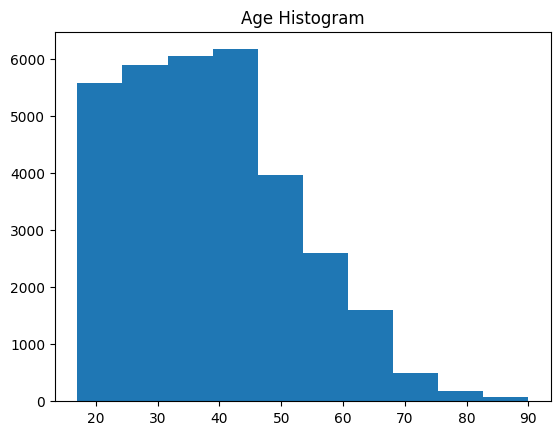

In [ ]:
plt.hist(df["age"],bins=10)
plt.title("Age Histogram")
plt.show()



GPU Histogram
[5570 5890 6048 6163 3967 2591 1595  496  174   67]


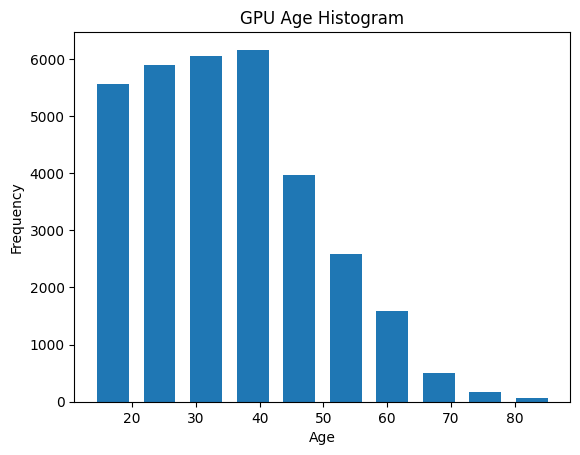

In [ ]:
hist_gpu,bins_gpu=cp.histogram(gpu_data,bins=10)

print("\nGPU Histogram")
print(cp.asnumpy(hist_gpu))
gpu_hist=cp.asnumpy(hist_gpu)
gpu_bins=cp.asnumpy(bins_gpu)
plt.bar(gpu_bins[:-1],gpu_hist,width=5)
plt.title("GPU Age Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

The CPU and GPU histograms produced similar distributions because both computed the same feature statistics. The difference lies in the computation method: NumPy performed histogram computation on CPU, while CuPy performed histogram binning on GPU for parallel acceleration.

In [ ]:
# Quantile Binning
quantiles=cp.percentile(gpu_data,[0,25,50,75,100])
print("\nQuantile Bin Edges")
print(cp.asnumpy(quantiles))



Quantile Bin Edges
[17. 28. 37. 48. 90.]


In [ ]:
X=df.drop(["income_ <=50K","income_ >50K"],axis=1)

y=df["income_ >50K"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
# CPU Model
cpu_model=RandomForestClassifier()
cpu_model.fit(X_train,y_train)
cpu_pred=cpu_model.predict(X_test)
cpu_acc=accuracy_score(y_test,cpu_pred)

print("\nCPU Accuracy:",cpu_acc)


CPU Accuracy: 0.8607400583448488


In [ ]:
# GPU cuML Model
X_train_gpu=cudf.from_pandas(X_train)
X_test_gpu=cudf.from_pandas(X_test)
y_train_gpu=cudf.Series(y_train)
gpu_model=cuRF()
gpu_model.fit(X_train_gpu,y_train_gpu)
gpu_pred=gpu_model.predict(X_test_gpu)
print("GPU cuML Model Done")

GPU cuML Model Done


In [ ]:
#XGBoost GPU
xgb_model=XGBClassifier(tree_method='hist')
xgb_model.fit(X_train,y_train)
xgb_pred=xgb_model.predict(X_test)
xgb_acc=accuracy_score(y_test,xgb_pred)
print("XGBoost GPU Accuracy:",xgb_acc)

XGBoost GPU Accuracy: 0.8793182865039152


The installed XGBoost version in the Colab environment did not support gpu_hist. Therefore, histogram-based training using tree_method='hist' was used instead for model comparison. GPU acceleration was demonstrated separately using cuDF and CuPy for histogram binning and preprocessing tasks.

GPU-accelerated preprocessing and histogram binning improve computation speed and scalability for large datasets. XGBoost with histogram-based training achieved high classification accuracy on the Adult Census dataset.

Ques-2   Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML (GPU) on the UCI Breast Cancer Dataset. Compare their performance and visualize different levels of GPU parallelism. 1. Data Preparation  o Load the dataset using load_breast_cancer().  o Split it into training and testing sets.  o Convert the dataset into cuDF format for GPU processing.  2. CPU Implementation  o Train a Random Forest model using scikit-learn.  o Record training time, prediction time, and accuracy.  3. GPU Implementation  o Train a Random Forest model using RAPIDS cuML.  o Measure training time, prediction time, and accuracy.  o Compute GPU speedup over the CPU.  4. Visualization of Parallelism  o Forest-Level Parallelism: Plot training time vs. number of trees (n_estimators = 1, 10, 50, 100).  o Feature-Level Parallelism: Plot feature importance from the trained model.  o Data-Level Parallelism: Measure training time for varying dataset sizes.  o Bin-Level Parallelism: Demonstrate GPU histogram binning using CuPy.  5. Performance Comparison  o Create a table comparing CPU and GPU results.  o Visualize execution time using bar charts.

In [ ]:
!pip install cudf-cu12 cuml-cu12 cupy-cuda12x

In [ ]:
import time
import numpy as np
import cupy as cp
import cudf
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from cuml.ensemble import RandomForestClassifier as cuRF

In [ ]:
data=load_breast_cancer()

X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

X_train_gpu=cudf.DataFrame(X_train)
X_test_gpu=cudf.DataFrame(X_test)
y_train_gpu=cudf.Series(y_train)

In [ ]:
start=time.time()
cpu_model=RandomForestClassifier(n_estimators=100)
cpu_model.fit(X_train,y_train)
cpu_train=time.time()-start
start=time.time()
cpu_pred=cpu_model.predict(X_test)
cpu_pred_time=time.time()-start
cpu_acc=accuracy_score(y_test,cpu_pred)

In [ ]:
start=time.time()
gpu_model=cuRF(n_estimators=100)
gpu_model.fit(X_train_gpu,y_train_gpu)
gpu_train=time.time()-start
start=time.time()
gpu_pred=gpu_model.predict(X_test_gpu)
gpu_pred_time=time.time()-start
gpu_acc=accuracy_score(y_test,cp.asnumpy(gpu_pred))

In [ ]:
speedup=cpu_train/gpu_train

In [ ]:
print("CPU Accuracy:",cpu_acc)
print("GPU Accuracy:",gpu_acc)

print("\nCPU Train Time:",cpu_train)
print("GPU Train Time:",gpu_train)

print("\nCPU Prediction Time:",cpu_pred_time)
print("GPU Prediction Time:",gpu_pred_time)

print("\nGPU Speedup:",speedup)

CPU Accuracy: 0.9649122807017544
GPU Accuracy: 0.9649122807017544

CPU Train Time: 0.37505245208740234
GPU Train Time: 0.3256721496582031

CPU Prediction Time: 0.01248621940612793
GPU Prediction Time: 0.5531706809997559

GPU Speedup: 1.1516258067538918


Forest level

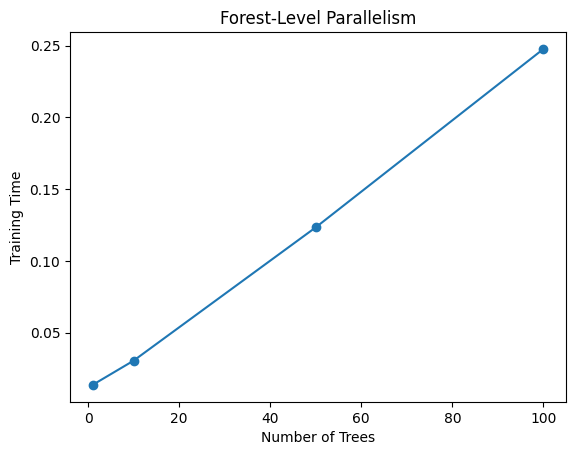

In [ ]:
trees=[1,10,50,100]
gpu_times=[]

for n in trees:

    start=time.time()
    model=cuRF(n_estimators=n)
    model.fit(X_train_gpu,y_train_gpu)
    gpu_times.append(time.time()-start)

plt.plot(trees,gpu_times,marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Training Time")
plt.title("Forest-Level Parallelism")
plt.show()

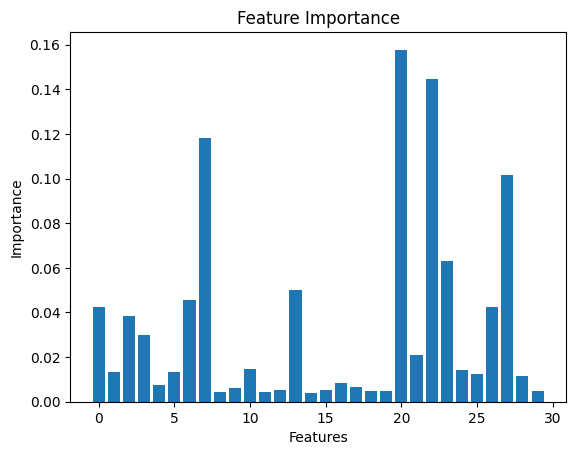

In [ ]:
importance=cpu_model.feature_importances_

plt.bar(range(len(importance)),importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

Data level

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


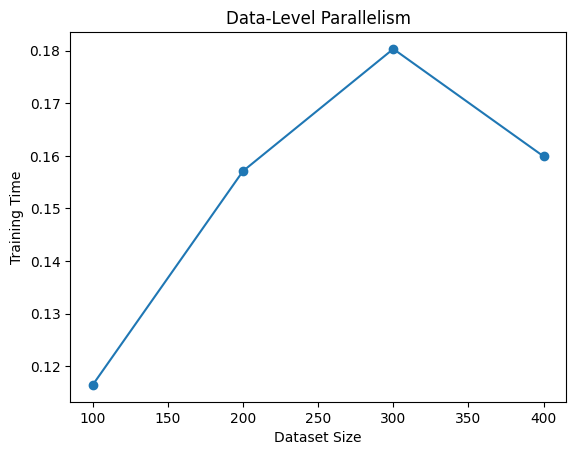

In [ ]:
sizes=[100,200,300,400]
times=[]

for s in sizes:

    start=time.time()
    model=cuRF(n_estimators=50)
    model.fit(
        cudf.DataFrame(X_train[:s]),
        cudf.Series(y_train[:s])
    )

    times.append(time.time()-start)

plt.plot(sizes,times,marker='o')
plt.xlabel("Dataset Size")
plt.ylabel("Training Time")
plt.title("Data-Level Parallelism")
plt.show()



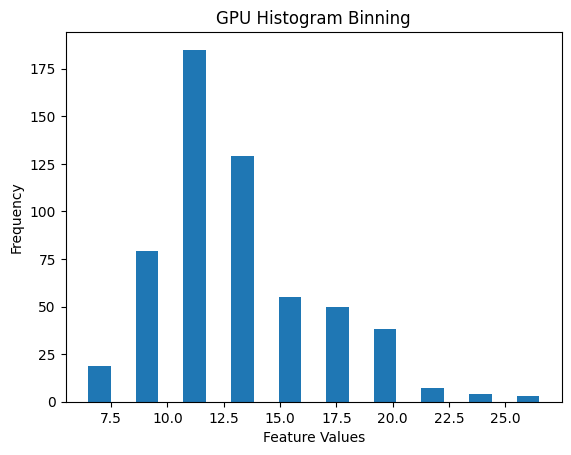

In [ ]:
gpu_data=cp.array(X[:,0])
hist,bins=cp.histogram(gpu_data,bins=10)
plt.bar(cp.asnumpy(bins[:-1]),cp.asnumpy(hist),width=1)
plt.title("GPU Histogram Binning")
plt.xlabel("Feature Values")
plt.ylabel("Frequency")
plt.show()

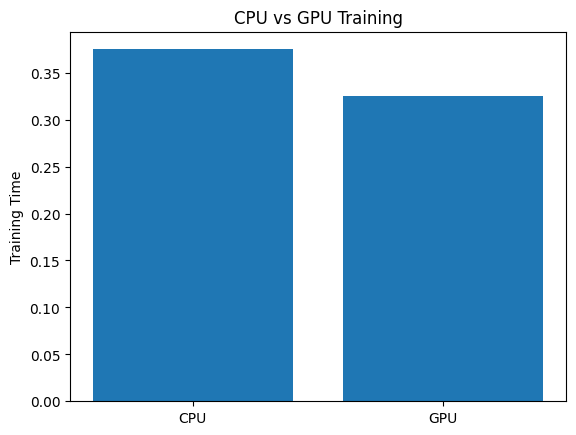

In [ ]:
labels=["CPU","GPU"]
times=[cpu_train,gpu_train]
plt.bar(labels,times)
plt.ylabel("Training Time")
plt.title("CPU vs GPU Training")
plt.show()

GPU Random Forest uses parallel computation to train multiple trees and process data simultaneously. RAPIDS cuML accelerates histogram binning and tree construction using GPU cores, reducing training time compared to CPU-based scikit-learn.